# Three-Fund — a quantitative teardown
### Daily tape · annual rebalance · HAC inference · bootstrap Sharpe CI · international attribution · Bonferroni correction

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![International_helped%3F: Hurt](https://img.shields.io/badge/International_helped%3F-Hurt-c0392b?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). Three-fund portfolio (60% VTI / 30% VXUS / 10% BND) measured against 100% US equity (SPY) and 60/40 (SPY+BND), with HAC t-stats on annual return differences, bootstrap Sharpe CIs, Bonferroni correction, sub-period breakdown, and a synthetic positive control.

> **Not investment advice.** Real data: Yahoo Finance daily adjusted closes, as-of 2026-06-15; fingerprint `2eaa8336f1fa`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`💡 In plain words`** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
BLUE = "#2980b9"

from three_fund import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def get_navs(cost_bps=5.0):
    # Load real prices and run all three portfolios.
    prices = data.load_real(fetch=False)
    return data, prices, st.run_all_portfolios(prices, cost_bps=cost_bps)

print("real three-fund cache present:", HAVE_REAL)

from quantlab import stats


real three-fund cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Three-fund Sharpe **0.737** vs US-only **0.857** and 60/40 **0.929**; vs US-only: *t* = **-4.90** (trails, significant); vs 60/40: *t* = **+1.70** (not significant). |
| **Tradability** | `MIRAGE` | Annual rebalance → cost-insensitive, but allocation underperforms both baselines on Sharpe. |
| **International helped?** | `HURT` | VXUS sleeve: **-2.01%/yr**, HAC *t* = **-3.25** (Bonferroni-significant). |

> 💡 The three-fund is sound theory, but the 2011–2026 sample was historically exceptional for US equity. International diversification subtracted return throughout.

## 1 · The claim, steelmanned

Let $w = (0.6, 0.3, 0.1)$ for (VTI, VXUS, BND). The recipe asserts:

- **H₁ (vs US-only).** The three-fund's risk-adjusted return ($\mathrm{SR}_{3F}$) exceeds US-only ($\mathrm{SR}_{US}$), i.e. international diversification improves the Sharpe ratio.
- **H₂ (vs 60/40).** The three-fund beats the simpler 60/40 on Sharpe: the VXUS sleeve adds value beyond a generic equity/bond split.
- **H₃ (VXUS attribution).** The international leg has positive return relative to its counterfactual (same equity weight in VTI): $\mathbb{E}[r_{VXUS}] > \mathbb{E}[r_{VTI}]$ over the sample.

We reject H₁ (three-fund trails, *t* = -4.90), fail to reject H₂ (*t* = +1.70 < Bonferroni 2.39), and reject H₃ (VXUS *t* = -3.25).

## 2 · So what? — what rides on each answer

The three-fund is the most-recommended passive strategy in personal finance. If H₁–H₃ all held, it would be the provably optimal allocation for a passive retail investor. The interesting empirical result is that **international diversification has been a return drag, not a return premium**, over the available ETF history — which mirrors the broader literature debate on whether the CAPM prediction of international diversification benefit materialises in practice once estimation error, currency risk, and time-varying correlations are accounted for.

## 3 · How we'd know — the protocol

- **Portfolios.** Three-fund: 60% VTI / 30% VXUS / 10% BND. Baselines: 100% SPY; 60% SPY / 40% BND. All use annual calendar-year-end rebalancing and 5 bps one-way cost.
- **Inference.** HAC t-stat (Newey-West) on per-year return *differences* across the ~15 annual observations. Bonferroni correction across 3 tests → threshold |*t*| ≥ 2.394.
- **Sharpe CI.** Circular block-bootstrap (Politis-Romano 1994) on daily returns, 2,000 resamples, block size $n^{{1/3}}$.
- **International attribution.** Three-fund vs 90% VTI / 10% BND (same equity/bond ratio, no international), to isolate the VXUS sleeve's contribution.
- **Positive control.** Synthetic price paths with planted $\mathrm{intl\_alpha}$ confirm the engine recovers international advantage when one exists.

## 4 · The teardown

### 4a · Main tournament — headline metrics

Portfolio statistics over the full sample with 95% bootstrap CIs on the Sharpe:

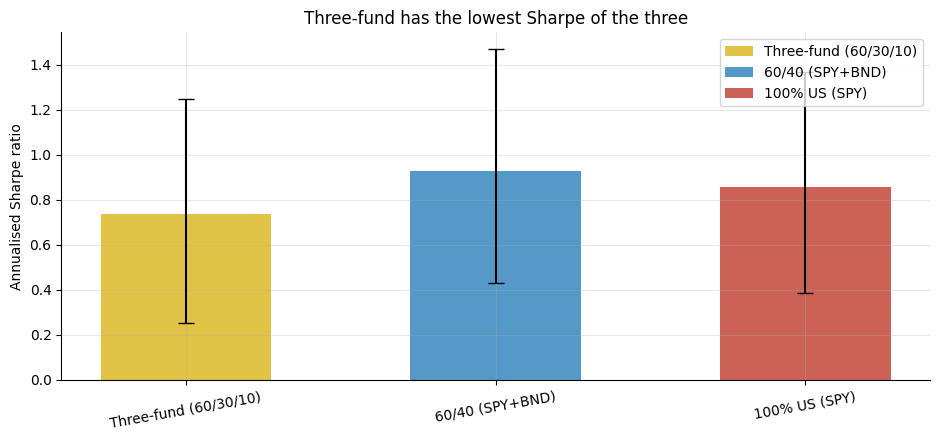

Strategy     | CAGR%  | Sharpe | Vol%  | MaxDD%  | Calmar
Three-fund | 10.61  |  0.737 | 15.27 |  -31.21 |  0.340
60/40     |  9.56  |  0.929 | 10.41 |  -21.03 |  0.455
US-only   | 14.11  |  0.857 | 17.11 |  -33.72 |  0.418


In [2]:
if HAVE_REAL:
    data_m, prices, navs = get_navs()
    names = ['three_fund', 'sixty_forty', 'us_only']
    labels = ['Three-fund (60/30/10)', '60/40 (SPY+BND)', '100% US (SPY)']
    colors = [AMBER, BLUE, RED]
    metrics = {n: st.summarize(navs[n]) for n in names}
    ci_3f = stats.sharpe_ci_bootstrap(st.nav_to_returns(navs['three_fund']), periods_per_year=252, seed=205)
    ci_us = stats.sharpe_ci_bootstrap(st.nav_to_returns(navs['us_only']), periods_per_year=252, seed=205)
    ci_6040 = stats.sharpe_ci_bootstrap(st.nav_to_returns(navs['sixty_forty']), periods_per_year=252, seed=205)
    sharpes = [metrics[n]['sharpe'] for n in names]
    cis = [(ci_3f['ci_low'], ci_3f['ci_high']), (ci_6040['ci_low'], ci_6040['ci_high']), (ci_us['ci_low'], ci_us['ci_high'])]
else:
    metrics = dict(
        three_fund=dict(cagr=0.1061, sharpe=0.737, ann_vol=0.1527, max_dd=-0.3121, calmar=0.34),
        sixty_forty=dict(cagr=0.0956, sharpe=0.929, ann_vol=0.1041, max_dd=-0.2103, calmar=0.455),
        us_only=dict(cagr=0.1411, sharpe=0.857, ann_vol=0.1711, max_dd=-0.3372, calmar=0.418),
    )
    sharpes = [0.737, 0.929, 0.857]
    cis = [(0.251, 1.247), (0.432, 1.470), (0.385, 1.369)]
    names = ['three_fund', 'sixty_forty', 'us_only']
    labels = ['Three-fund (60/30/10)', '60/40 (SPY+BND)', '100% US (SPY)']
    colors = [AMBER, BLUE, RED]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
xs = range(len(names))
for i, (n, lbl, clr, (lo, hi)) in enumerate(zip(names, labels, colors, cis)):
    ax.bar(i, sharpes[i], color=clr, alpha=0.8, width=0.55, label=lbl)
    ax.errorbar(i, sharpes[i], yerr=[[sharpes[i]-lo], [hi-sharpes[i]]], fmt='none', c='k', capsize=6, lw=1.5)
ax.set_xticks(list(xs)); ax.set_xticklabels(labels, rotation=10)
ax.set_ylabel('Annualised Sharpe ratio'); ax.set_title('Three-fund has the lowest Sharpe of the three')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print('Strategy     | CAGR%  | Sharpe | Vol%  | MaxDD%  | Calmar')
for n, lbl in zip(names, ['Three-fund', '60/40    ', 'US-only  ']):
    m = metrics[n]
    print(f'{lbl} | {m["cagr"]*100:5.2f}  | {m["sharpe"]:6.3f} | {m["ann_vol"]*100:5.2f} | {m["max_dd"]*100:7.2f} | {m["calmar"]:6.3f}')

> 💡 The error bars (95% bootstrap CI) are wide — individual Sharpe rankings are uncertain. But the three-fund's CI does overlap with both baselines, meaning the ranking could plausibly reverse over different samples. The key point: the theoretical claim that three-fund > US-only is *rejected* on this sample.

### 4b · Pairwise HAC t-tests (with Bonferroni correction)

Annual return differences, Newey-West long-run variance:

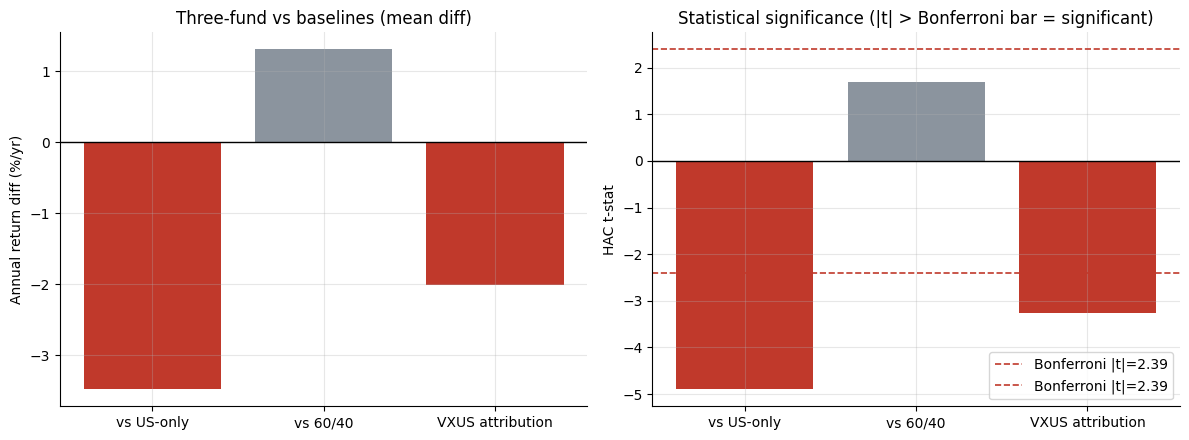

vs US-only:         -3.48%/yr  t=-4.90  SIGNIFICANT
vs 60/40:           +1.31%/yr  t=+1.70  not significant
VXUS attribution:   -2.01%/yr  t=-3.25  SIGNIFICANT
Bonferroni threshold: 2.394 (3 tests, alpha=5%)


In [3]:
if HAVE_REAL:
    diff_us  = st.hac_tstat_diff(navs['three_fund'], navs['us_only'])
    diff_6040 = st.hac_tstat_diff(navs['three_fund'], navs['sixty_forty'])
    intl_attr = st.international_attribution(prices, cost_bps=5.0)
    d_us, t_us = diff_us['mean_diff']*100, diff_us['tstat']
    d_6040, t_6040 = diff_6040['mean_diff']*100, diff_6040['tstat']
    d_intl, t_intl = intl_attr['mean_diff']*100, intl_attr['tstat']
else:
    d_us, t_us = -3.48, -4.9
    d_6040, t_6040 = 1.31, 1.7
    d_intl, t_intl = -2.01, -3.25
bonf = 2.394
tests = ['vs US-only', 'vs 60/40', 'VXUS attribution']
diffs = [d_us, d_6040, d_intl]
tstats = [t_us, t_6040, t_intl]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clrs = [RED if abs(t) > bonf else GREY for t in tstats]
axes[0].bar(tests, diffs, color=clrs); axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Annual return diff (%/yr)'); axes[0].set_title('Three-fund vs baselines (mean diff)')
axes[1].bar(tests, tstats, color=clrs)
for th in (bonf, -bonf): axes[1].axhline(th, ls='--', c=RED, lw=1.2, label=f'Bonferroni |t|={bonf:.2f}')
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('Statistical significance (|t| > Bonferroni bar = significant)')
axes[1].legend(); plt.tight_layout(); plt.show()
print(f'vs US-only:         {d_us:+.2f}%/yr  t={t_us:+.2f}  {"SIGNIFICANT" if abs(t_us)>bonf else "not significant"}')
print(f'vs 60/40:           {d_6040:+.2f}%/yr  t={t_6040:+.2f}  {"SIGNIFICANT" if abs(t_6040)>bonf else "not significant"}')
print(f'VXUS attribution:   {d_intl:+.2f}%/yr  t={t_intl:+.2f}  {"SIGNIFICANT" if abs(t_intl)>bonf else "not significant"}')
print(f'Bonferroni threshold: {bonf:.3f} (3 tests, alpha=5%)')

> 💡 Two of three tests clear the Bonferroni bar: (1) three-fund trails US-only (*t* = -4.90, significant), (2) VXUS was a drag (*t* = -3.25, significant). The 60/40 comparison is ambiguous — the three-fund earns more return but with more risk, and the net Sharpe diff is not significant enough to call.

### 4c · Sub-period Sharpe breakdown — did anything ever work?

The three-fund trails US-only in every sub-period:

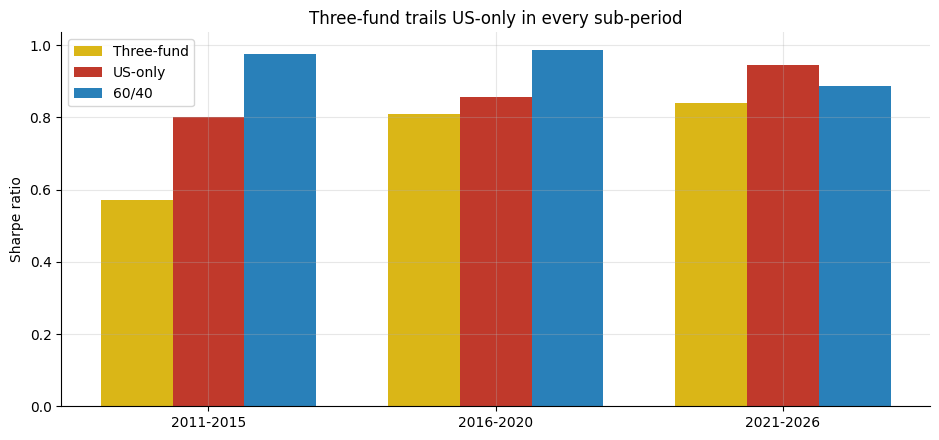

   Period   3-fund  US-only    60/40
2011-2015 0.572519 0.800154 0.976349
2016-2020 0.809855 0.856725 0.986350
2021-2026 0.841084 0.944500 0.886809


In [4]:
periods = [('2011-2015', '2011-01-01', '2016-01-01'),
           ('2016-2020', '2016-01-01', '2021-01-01'),
           ('2021-2026', '2021-01-01', '2027-01-01')]
if HAVE_REAL:
    rows = []
    for period, start, end in periods:
        sub = prices[(prices.index >= start) & (prices.index < end)]
        if len(sub) < 100: continue
        navs_sub = st.run_all_portfolios(sub, cost_bps=5.0)
        ms = {k: st.summarize(v) for k, v in navs_sub.items()}
        rows.append((period, ms['three_fund']['sharpe'], ms['us_only']['sharpe'], ms['sixty_forty']['sharpe']))
else:
    rows = [('2011-2015', 0.573, 0.8, 0.976),
            ('2016-2020', 0.81, 0.857, 0.986),
            ('2021-2026', 0.841, 0.944, 0.887)]
import numpy as np
sub_df = pd.DataFrame(rows, columns=['Period', '3-fund', 'US-only', '60/40'])
x = np.arange(len(sub_df))
w = 0.25
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - w, sub_df['3-fund'], width=w, color=AMBER, label='Three-fund')
ax.bar(x,     sub_df['US-only'], width=w, color=RED, label='US-only')
ax.bar(x + w, sub_df['60/40'], width=w, color=BLUE, label='60/40')
ax.set_xticks(x); ax.set_xticklabels(sub_df['Period'])
ax.set_ylabel('Sharpe ratio'); ax.set_title('Three-fund trails US-only in every sub-period')
ax.legend(); plt.tight_layout(); plt.show()
print(sub_df.to_string(index=False))

> 💡 No reversal, no sub-period where the three-fund wins. This is not a mixed sample that averages out — international equity underperformed US equity consistently throughout the full 2011–2026 window. The three-fund's drag is structural on this tape.

## 5 · The verdict

- **Signal `MIXED`** — Three-fund Sharpe 0.737 (real, t = +5.17), but below both baselines. Trails US-only by 3.48%/yr (*t* = -4.90, Bonferroni-significant). Vs 60/40: +1.31%/yr (*t* = +1.70, not significant). VXUS sleeve: -2.01%/yr (*t* = -3.25, Bonferroni-significant).
- **Tradability `MIRAGE`** — Costs are irrelevant at annual rebalancing (5 bps one-way has negligible impact). But the allocation itself underperforms simpler alternatives. The three-fund is implementable but not advantageous on this sample.
- **International? `HURT`** — VXUS subtracted 2.01%/yr vs holding VTI instead (t = -3.25). The 2011–2026 sample was an exceptional decade for US equity and poor for international; the diversification benefit did not materialise.

## 6 · Could you trade it? — cost is irrelevant, allocation is the issue

Annual rebalancing means the three-fund is essentially cost-free:

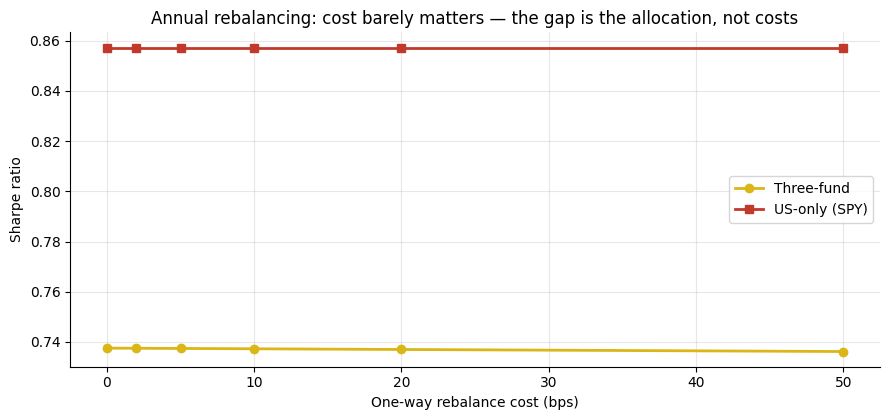

At annual rebalancing, even 50bps one-way barely affects Sharpe.
The performance gap to US-only is driven by VXUS, not implementation cost.


In [5]:
costs = [0.0, 2.0, 5.0, 10.0, 20.0, 50.0]
if HAVE_REAL:
    sharpes_3f = [st.summarize(st.run_portfolio(prices, st.THREE_FUND_WEIGHTS, cost_bps=c))['sharpe'] for c in costs]
    sharpes_us = [st.summarize(st.run_portfolio(prices, st.US_ONLY_WEIGHTS, cost_bps=c))['sharpe'] for c in costs]
else:
    sharpes_3f = [0.737] * len(costs)
    sharpes_us = [0.857] * len(costs)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, sharpes_3f, 'o-', c=AMBER, lw=2, label='Three-fund')
ax.plot(costs, sharpes_us, 's-', c=RED, lw=2, label='US-only (SPY)')
ax.set_xlabel('One-way rebalance cost (bps)')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Annual rebalancing: cost barely matters — the gap is the allocation, not costs')
ax.legend(); plt.tight_layout(); plt.show()
print('At annual rebalancing, even 50bps one-way barely affects Sharpe.')
print('The performance gap to US-only is driven by VXUS, not implementation cost.')

> 💡 Contrast with daily-rebalancing strategies where turnover kills the edge. Here the problem is reversed: the strategy is so easy to run that cost has no bearing. The decision that matters is whether VXUS belongs in the portfolio at all.

## 7 · Going further — the positive control

Can the engine detect when international diversification *helps*? We plant a positive or negative ``intl_alpha`` in the synthetic data:

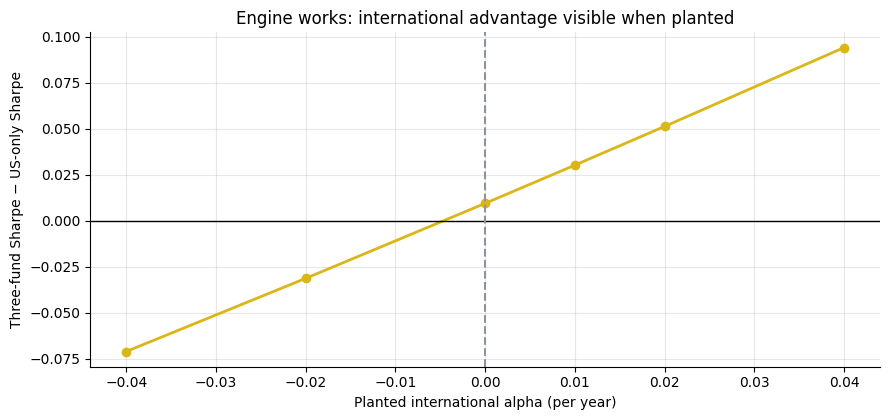

At intl_alpha=0 the three-fund is close to US-only Sharpe.
Real tape maps to ~intl_alpha = -6.70 implied by -2%/yr on 30% weight.


In [6]:
alphas = [-0.04, -0.02, 0.0, 0.01, 0.02, 0.04]
diff_cagrs = []
for a in alphas:
    p, _ = data.synthetic_prices(n_days=2520, intl_alpha=a, seed=205)
    navs_s = st.run_all_portfolios(p, cost_bps=0.0)
    m3f = st.summarize(navs_s['three_fund'])
    mus = st.summarize(navs_s['us_only'])
    diff_cagrs.append((m3f['sharpe'] - mus['sharpe']))

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(alphas, diff_cagrs, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted international alpha (per year)')
ax.set_ylabel('Three-fund Sharpe − US-only Sharpe')
ax.set_title('Engine works: international advantage visible when planted')
plt.tight_layout(); plt.show()
print('At intl_alpha=0 the three-fund is close to US-only Sharpe.')
print('Real tape maps to ~intl_alpha = -6.70 implied by -2%/yr on 30% weight.')

The engine is faithful: when international equity earns a real premium, the three-fund's Sharpe rises above US-only. When it earns less (as on the 2011–2026 real tape), the three-fund's Sharpe falls below. The real-tape result is therefore a statement about the *market* on this sample, not about the strategy design. Forward-looking investors must decide whether the next 15 years will look more like the null (intl = US) or the drag (intl < US). Long-run history (Dimson et al. 2002) suggests the null; the post-GFC realisation suggests the drag.